📂 Loading mood series data...

📊 Distribusi Mood:
       Mood  Count
0  Negative   1032
1  Positive    189


C:\Users\nanda\AppData\Local\Temp\ipykernel_24664\2372648247.py:70: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=mood_counts, x="Mood", y="Count", palette=["green", "gray", "red"])
C:\Users\nanda\AppData\Local\Temp\ipykernel_24664\2372648247.py:70: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sns.barplot(data=mood_counts, x="Mood", y="Count", palette=["green", "gray", "red"])


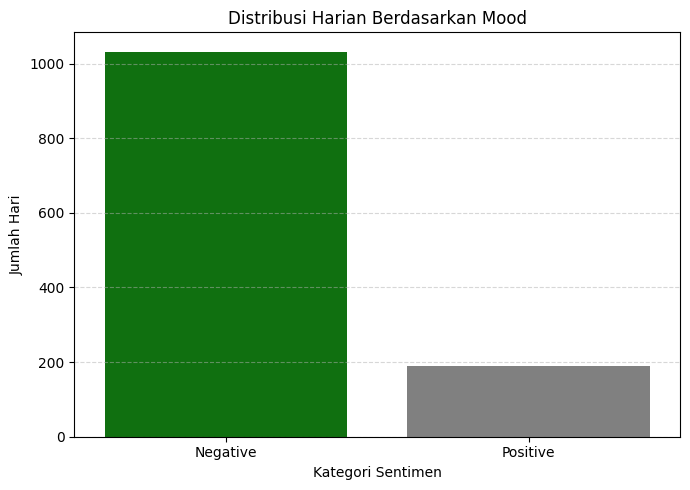

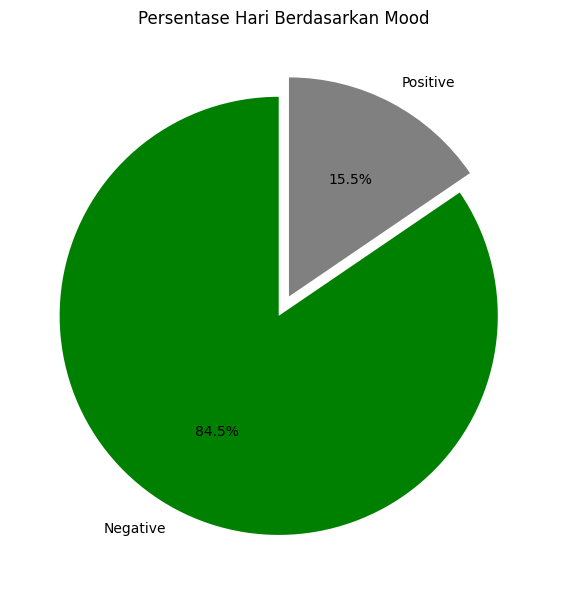

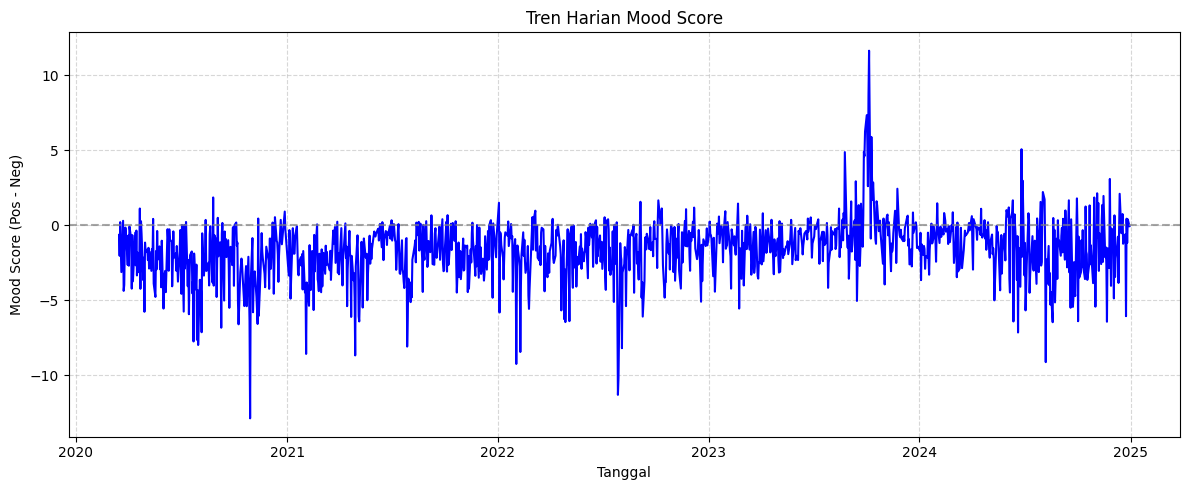


✅ Visualisasi mood series selesai!


In [5]:
#!/usr/bin/env python3
"""
visualize_mood_series.py
Visualisasi distribusi dan tren Mood Score (positif, negatif, netral)
dari file mood_series.xlsx.
"""

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# ==========================================
# CONFIG
# ==========================================
mood_file = r"D:\Skripsi\Data\Kode Ekstrak\output\mood_series.xlsx"

# ==========================================
# LOAD DATA
# ==========================================
print("📂 Loading mood series data...")
if not os.path.exists(mood_file):
    raise FileNotFoundError(f"❌ File tidak ditemukan: {mood_file}")

df = pd.read_excel(mood_file)

# --- Normalisasi nama kolom ---
df.columns = df.columns.str.lower().str.strip()

# --- Validasi kolom utama ---
if "mood_score" not in df.columns:
    print(f"❌ Kolom yang tersedia: {df.columns.tolist()}")
    raise ValueError("Kolom 'mood_score' tidak ditemukan di file mood_series.xlsx")

# --- Konversi kolom tanggal ---
date_col = [c for c in df.columns if "date" in c]
if not date_col:
    raise ValueError("❌ Tidak ditemukan kolom tanggal.")
else:
    df["date"] = pd.to_datetime(df[date_col[0]], errors="coerce")
    df = df.dropna(subset=["date"])

# --- Pastikan nilai mood_score adalah numerik ---
df["mood_score"] = pd.to_numeric(df["mood_score"], errors="coerce")
df = df.dropna(subset=["mood_score"])

# ==========================================
# KATEGORIKAN SENTIMEN
# ==========================================
def categorize_mood(score):
    if score > 0:
        return "Positive"
    elif score < 0:
        return "Negative"
    else:
        return "Neutral"

df["Mood_Category"] = df["mood_score"].apply(categorize_mood)

# Hitung distribusi kategori
mood_counts = df["Mood_Category"].value_counts().reset_index()
mood_counts.columns = ["Mood", "Count"]
print("\n📊 Distribusi Mood:")
print(mood_counts)

# ==========================================
# VISUALISASI 1: Bar Chart
# ==========================================
plt.figure(figsize=(7, 5))
sns.barplot(data=mood_counts, x="Mood", y="Count", palette=["green", "gray", "red"])
plt.title("Distribusi Harian Berdasarkan Mood")
plt.xlabel("Kategori Sentimen")
plt.ylabel("Jumlah Hari")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# ==========================================
# VISUALISASI 2: Pie Chart
# ==========================================
plt.figure(figsize=(6, 6))
plt.pie(
    mood_counts["Count"],
    labels=mood_counts["Mood"],
    autopct='%1.1f%%',
    colors=["green", "gray", "red"],
    startangle=90,
    explode=[0.05] * len(mood_counts)
)
plt.title("Persentase Hari Berdasarkan Mood")
plt.tight_layout()
plt.show()

# ==========================================
# VISUALISASI 3: Tren Mood Score Harian
# ==========================================
plt.figure(figsize=(12, 5))
sns.lineplot(data=df, x="date", y="mood_score", color="blue", linewidth=1.5)
plt.axhline(0, color="gray", linestyle="--", alpha=0.7)
plt.title("Tren Harian Mood Score")
plt.xlabel("Tanggal")
plt.ylabel("Mood Score (Pos - Neg)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

print("\n✅ Visualisasi mood series selesai!")


📂 Loading mood series data...

📊 Distribusi Mood:
       Mood  Count
0  Negative   1032
1  Positive    189


C:\Users\nanda\AppData\Local\Temp\ipykernel_24664\3404081728.py:70: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=mood_counts, x="Mood", y="Count", palette=["green", "gray", "red"])
C:\Users\nanda\AppData\Local\Temp\ipykernel_24664\3404081728.py:70: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sns.barplot(data=mood_counts, x="Mood", y="Count", palette=["green", "gray", "red"])


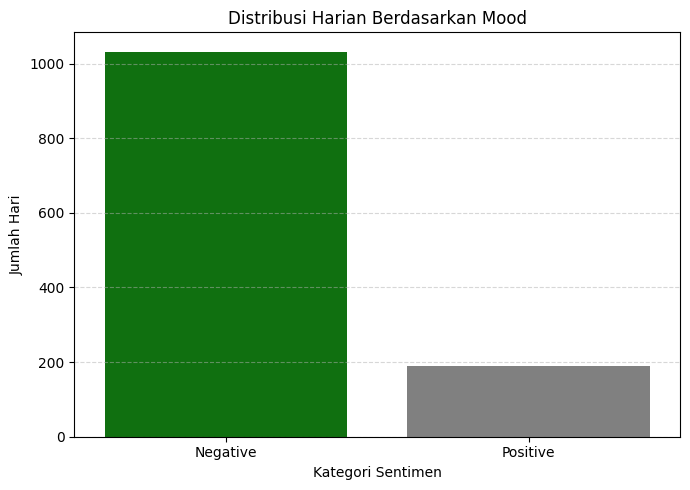

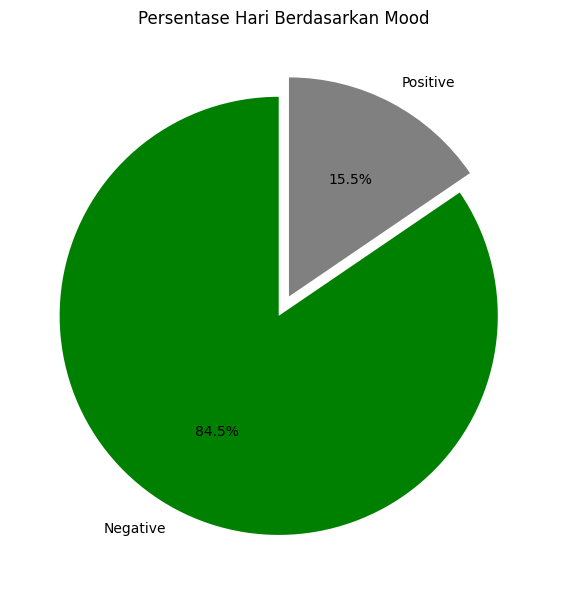

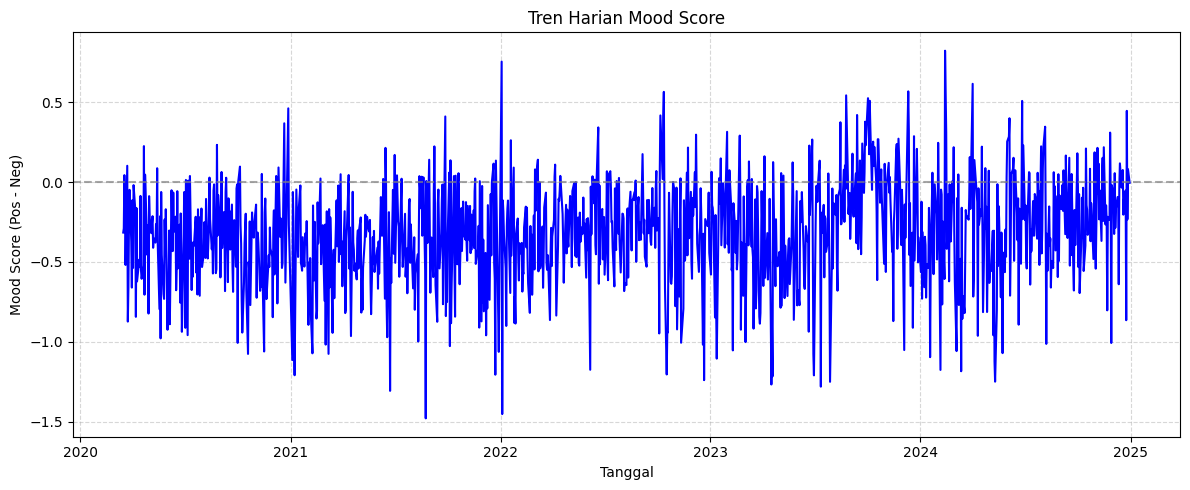


✅ Visualisasi mood series selesai!


In [4]:
#!/usr/bin/env python3
"""
visualize_mood_series.py
Visualisasi distribusi dan tren Mood Score (positif, negatif, netral)
dari file mood_series.xlsx.
"""

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# ==========================================
# CONFIG
# ==========================================
mood_file = r"D:\Skripsi\Data\Kode Ekstrak\output\mood_series_mean.xlsx"

# ==========================================
# LOAD DATA
# ==========================================
print("📂 Loading mood series data...")
if not os.path.exists(mood_file):
    raise FileNotFoundError(f"❌ File tidak ditemukan: {mood_file}")

df = pd.read_excel(mood_file)

# --- Normalisasi nama kolom ---
df.columns = df.columns.str.lower().str.strip()

# --- Validasi kolom utama ---
if "mood_score" not in df.columns:
    print(f"❌ Kolom yang tersedia: {df.columns.tolist()}")
    raise ValueError("Kolom 'mood_score' tidak ditemukan di file mood_series.xlsx")

# --- Konversi kolom tanggal ---
date_col = [c for c in df.columns if "date" in c]
if not date_col:
    raise ValueError("❌ Tidak ditemukan kolom tanggal.")
else:
    df["date"] = pd.to_datetime(df[date_col[0]], errors="coerce")
    df = df.dropna(subset=["date"])

# --- Pastikan nilai mood_score adalah numerik ---
df["mood_score"] = pd.to_numeric(df["mood_score"], errors="coerce")
df = df.dropna(subset=["mood_score"])

# ==========================================
# KATEGORIKAN SENTIMEN
# ==========================================
def categorize_mood(score):
    if score > 0:
        return "Positive"
    elif score < 0:
        return "Negative"
    else:
        return "Neutral"

df["Mood_Category"] = df["mood_score"].apply(categorize_mood)

# Hitung distribusi kategori
mood_counts = df["Mood_Category"].value_counts().reset_index()
mood_counts.columns = ["Mood", "Count"]
print("\n📊 Distribusi Mood:")
print(mood_counts)

# ==========================================
# VISUALISASI 1: Bar Chart
# ==========================================
plt.figure(figsize=(7, 5))
sns.barplot(data=mood_counts, x="Mood", y="Count", palette=["green", "gray", "red"])
plt.title("Distribusi Harian Berdasarkan Mood")
plt.xlabel("Kategori Sentimen")
plt.ylabel("Jumlah Hari")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# ==========================================
# VISUALISASI 2: Pie Chart
# ==========================================
plt.figure(figsize=(6, 6))
plt.pie(
    mood_counts["Count"],
    labels=mood_counts["Mood"],
    autopct='%1.1f%%',
    colors=["green", "gray", "red"],
    startangle=90,
    explode=[0.05] * len(mood_counts)
)
plt.title("Persentase Hari Berdasarkan Mood")
plt.tight_layout()
plt.show()

# ==========================================
# VISUALISASI 3: Tren Mood Score Harian
# ==========================================
plt.figure(figsize=(12, 5))
sns.lineplot(data=df, x="date", y="mood_score", color="blue", linewidth=1.5)
plt.axhline(0, color="gray", linestyle="--", alpha=0.7)
plt.title("Tren Harian Mood Score")
plt.xlabel("Tanggal")
plt.ylabel("Mood Score (Pos - Neg)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

print("\n✅ Visualisasi mood series selesai!")


In [16]:
import numpy as np

data_path = r"D:\Skripsi\Data\Kode Ekstrak\output\ModelC\processed_data.npz"
data = np.load(data_path)
print(data.files)
print(data["X_train"].shape)
print(data["y_train"].shape)
print(data["X_test"].shape)
print(data["y_test"].shape)

['X_train', 'y_train', 'X_test', 'y_test']
(931, 10, 8)
(931,)
(233, 10, 8)
(233,)
